In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("day.csv")
print("data set uploaded")
df.head()


data set uploaded


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
Q1 = df["windspeed"].quantile(0.25)
Q3 = df["windspeed"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["windspeed"] < lower) | (df["windspeed"] > upper)]

print(outliers)

     instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
44        45  2011-02-14       1   0     2        0        1           1   
49        50  2011-02-19       1   0     2        0        6           0   
93        94  2011-04-04       2   0     4        0        1           1   
94        95  2011-04-05       2   0     4        0        2           1   
292      293  2011-10-20       4   0    10        0        4           1   
382      383  2012-01-18       1   1     1        0        3           1   
407      408  2012-02-12       1   1     2        0        0           0   
420      421  2012-02-25       1   1     2        0        6           0   
432      433  2012-03-08       1   1     3        0        4           1   
433      434  2012-03-09       1   1     3        0        5           1   
450      451  2012-03-26       2   1     3        0        1           1   
666      667  2012-10-28       4   1    10        0        0           0   
721      722

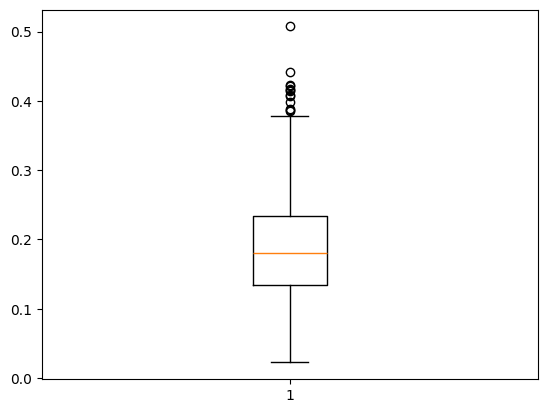

In [7]:
import matplotlib.pyplot as plt

plt.boxplot(df["windspeed"])
plt.show()

In [8]:
df = df[(df["windspeed"] >= lower) & (df["windspeed"] <= upper)]

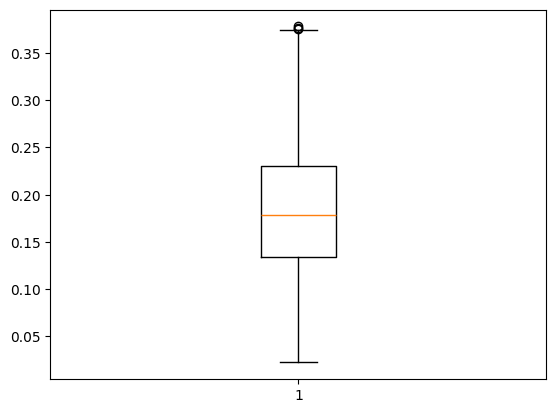

In [9]:
plt.boxplot(df["windspeed"])
plt.show()

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 718 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     718 non-null    int64  
 1   dteday      718 non-null    str    
 2   season      718 non-null    int64  
 3   yr          718 non-null    int64  
 4   mnth        718 non-null    int64  
 5   holiday     718 non-null    int64  
 6   weekday     718 non-null    int64  
 7   workingday  718 non-null    int64  
 8   weathersit  718 non-null    int64  
 9   temp        718 non-null    float64
 10  atemp       718 non-null    float64
 11  hum         718 non-null    float64
 12  windspeed   718 non-null    float64
 13  casual      718 non-null    int64  
 14  registered  718 non-null    int64  
 15  cnt         718 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 95.4 KB


In [11]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000
mean,366.364903,2.511142,0.498607,6.557103,0.029248,2.997214,0.685237,1.398329,0.497214,0.476126,0.630683,0.186392,855.814763,3671.583565,4527.398329
std,211.116876,1.106221,0.500347,3.439284,0.168618,2.000695,0.464745,0.546420,0.183533,0.163076,0.141107,0.071791,689.457718,1560.879937,1937.695290
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,184.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.338125,0.338045,0.524583,0.134331,317.250000,2517.250000,3206.500000
50%,364.500000,3.000000,0.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.504655,0.491160,0.630833,0.178802,725.500000,3676.500000,4566.500000
75%,549.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.611120,0.732813,0.230724,1119.500000,4805.500000,6021.250000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.378108,3410.000000,6946.000000,8714.000000


In [12]:
X = df.drop("cnt",axis = 1)
y = df["cnt"]

In [20]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train,y_test = train_test_split(
    X,y,test_size =0.2,random_state=42
)

In [15]:
X = df.drop(["cnt", "casual", "registered", "dteday", "instant"], axis=1)

In [16]:
categorical = ["season", "mnth", "weekday", "weathersit"]

df = pd.get_dummies(
    df,
    columns=categorical,
    drop_first=True
)

In [18]:
print(X_train.dtypes)

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
dtype: object


In [19]:
X = df.drop(["cnt", "dteday"], axis=1)
y = df["cnt"]

In [21]:
# feature scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
print(X_train.shape)
print(X_test.shape)

(574, 32)
(144, 32)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

model = Sequential([

    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),# make training faster,make training more stable,sometimes improve model performance
    Dropout(0.3), #Prevents overfitting.During training, it randomly turns off about 30% of the neurons.

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])


In [36]:
# compile
import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [37]:
# call back
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

In [52]:
# model training 
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 925409.3750 - mae: 679.1137

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1262241.8750 - mae: 871.0423 - val_loss: 574746.9375 - val_mae: 460.3854 - learning_rate: 1.0000e-05
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1104721.0000 - mae: 807.1185 - val_loss: 575219.3125 - val_mae: 460.8123 - learning_rate: 1.0000e-05
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1343570.3750 - mae: 900.2293 - val_loss: 577173.6875 - val_mae: 461.2357 - learning_rate: 1.0000e-05
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1173874.0000 - mae: 825.7687 - val_loss: 580770.2500 - val_mae: 461.6283 - learning_rate: 1.0000e-05
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1580966.2500 - mae: 964.1802 - val_loss: 582969.8125 - val_mae: 462.6102 - learning_rate: 1.0000e-05
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1334948.6250 - mae: 913.3406 - val_loss: 585823.8750 - val_mae: 463.9652 - learning_rate: 1.0000e-05
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

In [53]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [54]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as  np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 473.54779052734375
MSE : 753500.875
RMSE: 868.0442817045683
R2  : 0.8053979277610779


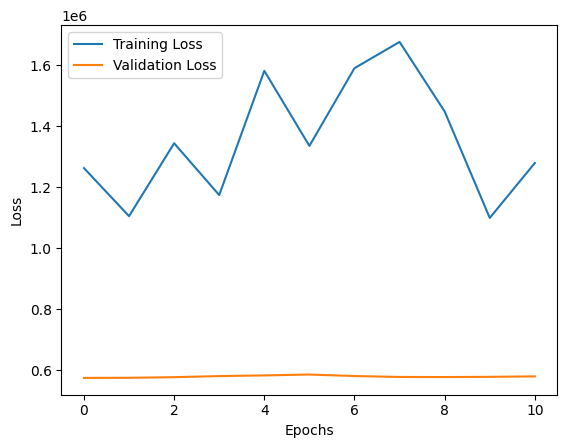

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Training R²: 0.9213556051254272
Test R²: 0.8053979277610779


In [57]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 25210636.0000 - mae: 4641.9160 - val_loss: 22288298.0000 - val_mae: 4300.5679
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25203728.0000 - mae: 4641.1982 - val_loss: 22285900.0000 - val_mae: 4300.3062
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25195798.0000 - mae: 4640.4321 - val_loss: 22282652.0000 - val_mae: 4299.9907
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25184836.0000 - mae: 4639.4341 - val_loss: 22276406.0000 - val_mae: 4299.4385
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25166712.0000 - mae: 4637.9282 - val_loss: 22262942.0000 - val_mae: 4298.3203
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25134896.0000 - mae: 4635.3530 - val_loss: 22231426.0000 - val_mae: 4295.7988
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25069516.0000 - mae: 4630.2969 - val_loss: 22156858.0000 - val_mae: 4289.9521
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0

In [61]:
print("Epochs completed:", len(history.history["loss"]))

Epochs completed: 89


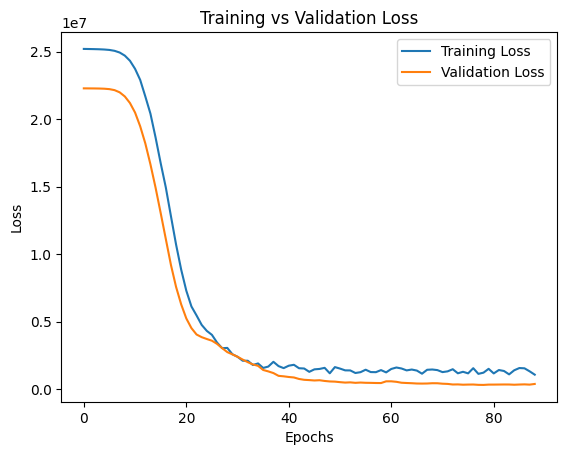

In [62]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [63]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Test R²:", test_r2)
print("R² Gap:", train_r2 - test_r2)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Training R²: 0.9571523666381836
Test R²: 0.9027300477027893
R² Gap: 0.05442231893539429
